In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math
from sklearn import metrics
import pickle

In [2]:
data=pd.read_csv('out time separated.csv')
data.head(20)

,Unnamed: 0,Gas_Type,CH4,Ar,N2,CO2,C,O,H,Shape,Detector_Size,Detector_Area,Cover_Size,Cover_Area,Cover_Area_Ratio,Voltage,Source,Time_Window,Peak_Count
0,0,p10,0.1,0.9,0.0,0.0,0.02,0.0,0.08,kare,10.0,100.0,6.0,36.0,0.36,8000,kaynaksız,1,18
1,1,p10,0.1,0.9,0.0,0.0,0.02,0.0,0.08,kare,10.0,100.0,6.0,36.0,0.36,8000,kaynaksız,1,11
2,2,p10,0.1,0.9,0.0,0.0,0.02,0.0,0.08,kare,10.0,100.0,6.0,36.0,0.36,8000,kaynaksız,1,11
3,3,p10,0.1,0.9,0.0,0.0,0.02,0.0,0.08,kare,10.0,100.0,6.0,36.0,0.36,8000,kaynaksız,1,13
4,4,p10,0.1,0.9,0.0,0.0,0.02,0.0,0.08,kare,10.0,100.0,6.0,36.0,0.36,8000,kaynaksız,1,11
5,5,p10,0.1,0.9,0.0,0.0,0.02,0.0,0.08,kare,10.0,100.0,6.0,36.0,0.36,8000,kaynaksız,1,16
6,6,p10,0.1,0.9,0.0,0.0,0.02,0.0,0.08,kare,10.0,100.0,6.0,36.0,0.36,8000,kaynaksız,1,17
7,7,p10,0.1,0.9,0.0,0.0,0.02,0.0,0.08,kare,10.0,100.0,6.0,36.0,0.36,8000,kaynaksız,1,10
8,8,p10,0.1,0.9,0.0,0.0,0.02,0.0,0.08,kare,10.0,100.0,6.0,36.0,0.36,8000,kaynaksız,1,11
9,9,p10,0.1,0.9,0.0,0.0,0.02,0.0,0.08,kare,10.0,100.0,6.0,36.0,0.36,8000,kaynaksız,1,15


In [3]:
data=data.sample(frac=1)
#data= data[data['Detector_Size'] == 10]
#data.drop(['Unnamed: 0','Shape','Detector_Size','Cover_Size','CH4','CO2'],axis=1,inplace=True)
#data= data.set_index('Event')


#data= data[data['Gas_Type'] != 'p10']
data.drop(['Shape'],axis=1,inplace=True)


data = data[data['Time_Window'].isin([10, 15, 25])]
#data.drop(['Time_Window'],axis=1,inplace=True)



#data= data[(data['Voltage'] >= 4500) & (data['Voltage'] <= 5500)]
#data= data[data['Detector_Size'] == 10]

#data.drop(['Voltage'],axis=1,inplace=True)


In [4]:
#groupByData = data.groupby(['Gas_Type', 'Detector_Size','Cover_Size','Voltage','Time_Window','Source'])

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7370 entries, 14616 to 14847
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        7370 non-null   int64  
 1   Gas_Type          7370 non-null   object 
 2   CH4               7370 non-null   float64
 3   Ar                7370 non-null   float64
 4   N2                7370 non-null   float64
 5   CO2               7370 non-null   float64
 6   C                 7370 non-null   float64
 7   O                 7370 non-null   float64
 8   H                 7370 non-null   float64
 9   Detector_Size     7370 non-null   float64
 10  Detector_Area     7370 non-null   float64
 11  Cover_Size        7370 non-null   float64
 12  Cover_Area        7370 non-null   float64
 13  Cover_Area_Ratio  7370 non-null   float64
 14  Voltage           7370 non-null   int64  
 15  Source            7370 non-null   object 
 16  Time_Window       7370 non-null   int64  


In [6]:
data.isnull()

,Unnamed: 0,Gas_Type,CH4,Ar,N2,CO2,C,O,H,Detector_Size,Detector_Area,Cover_Size,Cover_Area,Cover_Area_Ratio,Voltage,Source,Time_Window,Peak_Count
14616,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
32323,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
937,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
61112,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
24276,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35861,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
64400,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
17212,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
40807,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [7]:
data.isnull().sum()

Unnamed: 0          0
Gas_Type            0
CH4                 0
Ar                  0
N2                  0
CO2                 0
C                   0
O                   0
H                   0
Detector_Size       0
Detector_Area       0
Cover_Size          0
Cover_Area          0
Cover_Area_Ratio    0
Voltage             0
Source              0
Time_Window         0
Peak_Count          0
dtype: int64

<Axes: >

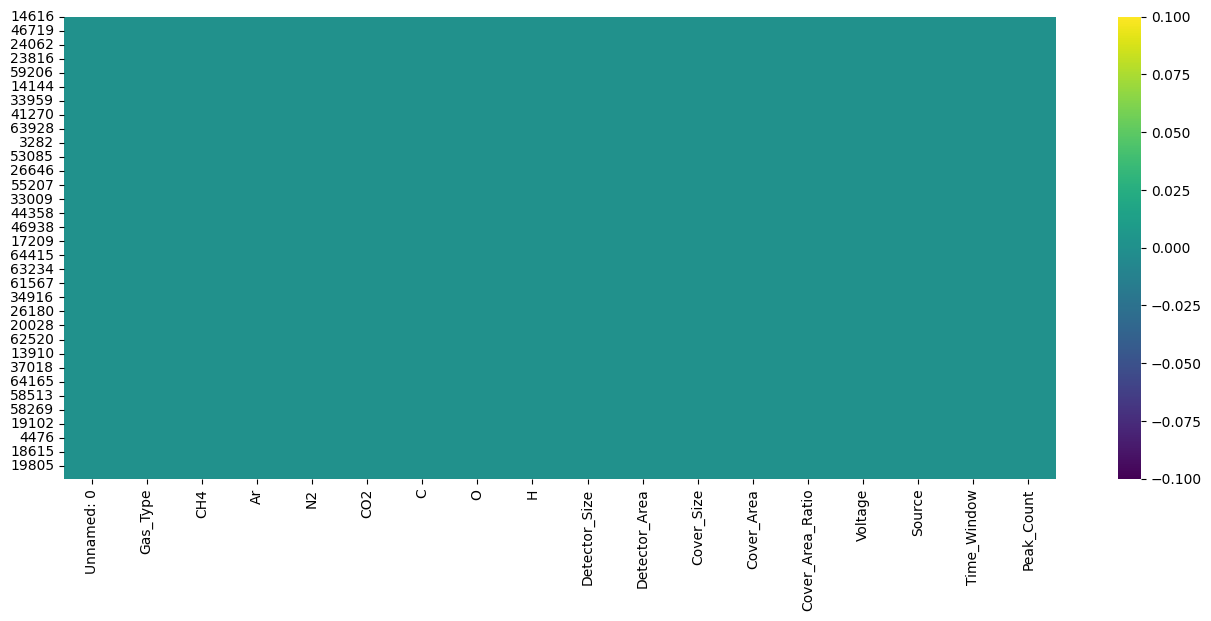

In [8]:
plt.figure(figsize=(16, 6))
sns.heatmap(data.isnull(),cmap='viridis')

In [9]:
data.dropna(inplace=True)

In [10]:
data.isnull().sum()

Unnamed: 0          0
Gas_Type            0
CH4                 0
Ar                  0
N2                  0
CO2                 0
C                   0
O                   0
H                   0
Detector_Size       0
Detector_Area       0
Cover_Size          0
Cover_Area          0
Cover_Area_Ratio    0
Voltage             0
Source              0
Time_Window         0
Peak_Count          0
dtype: int64

In [11]:
data.head()

,Unnamed: 0,Gas_Type,CH4,Ar,N2,CO2,C,O,H,Detector_Size,Detector_Area,Cover_Size,Cover_Area,Cover_Area_Ratio,Voltage,Source,Time_Window,Peak_Count
14616,14616,p10,0.1,0.90,0.00,0.0,0.02,0.0,0.08,10.00,100.00,8.00,64.00,0.64,3500,cs,15,103
32323,32323,p20,0.2,0.80,0.00,0.0,0.04,0.0,0.16,10.00,100.00,4.00,16.00,0.16,5000,cs,25,511
937,937,p10,0.1,0.90,0.00,0.0,0.02,0.0,0.08,10.00,100.00,6.00,36.00,0.36,8000,kaynaksız,15,918
61112,61112,arnco2,0.0,0.05,0.35,0.6,0.20,0.4,0.00,6.78,45.97,4.78,22.85,0.50,6500,cs,25,2272
24276,24276,p10,0.1,0.90,0.00,0.0,0.02,0.0,0.08,6.78,45.97,6.68,44.62,0.97,8000,cs,10,214


In [12]:
type2=pd.get_dummies(data['Gas_Type'],dtype=float)
type2

,arnco2,p10,p20
14616,0.0,1.0,0.0
32323,0.0,0.0,1.0
937,0.0,1.0,0.0
61112,1.0,0.0,0.0
24276,0.0,1.0,0.0
...,...,...,...
35861,0.0,0.0,1.0
64400,1.0,0.0,0.0
17212,0.0,1.0,0.0
40807,0.0,0.0,1.0


In [13]:
type=pd.get_dummies(data['Source'],dtype=float)
type

,cs,kaynaksız
14616,1.0,0.0
32323,1.0,0.0
937,0.0,1.0
61112,1.0,0.0
24276,1.0,0.0
...,...,...
35861,0.0,1.0
64400,0.0,1.0
17212,1.0,0.0
40807,1.0,0.0


In [14]:
data['KV2'] = (data['Voltage']/1000)**2
data.head()

,Unnamed: 0,Gas_Type,CH4,Ar,N2,CO2,C,O,H,Detector_Size,Detector_Area,Cover_Size,Cover_Area,Cover_Area_Ratio,Voltage,Source,Time_Window,Peak_Count,KV2
14616,14616,p10,0.1,0.90,0.00,0.0,0.02,0.0,0.08,10.00,100.00,8.00,64.00,0.64,3500,cs,15,103,12.25
32323,32323,p20,0.2,0.80,0.00,0.0,0.04,0.0,0.16,10.00,100.00,4.00,16.00,0.16,5000,cs,25,511,25.00
937,937,p10,0.1,0.90,0.00,0.0,0.02,0.0,0.08,10.00,100.00,6.00,36.00,0.36,8000,kaynaksız,15,918,64.00
61112,61112,arnco2,0.0,0.05,0.35,0.6,0.20,0.4,0.00,6.78,45.97,4.78,22.85,0.50,6500,cs,25,2272,42.25
24276,24276,p10,0.1,0.90,0.00,0.0,0.02,0.0,0.08,6.78,45.97,6.68,44.62,0.97,8000,cs,10,214,64.00


In [15]:
data=pd.concat([data,type2,type],axis=1)
data.head()

,Unnamed: 0,Gas_Type,CH4,Ar,N2,CO2,C,O,H,Detector_Size,...,Voltage,Source,Time_Window,Peak_Count,KV2,arnco2,p10,p20,cs,kaynaksız
14616,14616,p10,0.1,0.90,0.00,0.0,0.02,0.0,0.08,10.00,...,3500,cs,15,103,12.25,0.0,1.0,0.0,1.0,0.0
32323,32323,p20,0.2,0.80,0.00,0.0,0.04,0.0,0.16,10.00,...,5000,cs,25,511,25.00,0.0,0.0,1.0,1.0,0.0
937,937,p10,0.1,0.90,0.00,0.0,0.02,0.0,0.08,10.00,...,8000,kaynaksız,15,918,64.00,0.0,1.0,0.0,0.0,1.0
61112,61112,arnco2,0.0,0.05,0.35,0.6,0.20,0.4,0.00,6.78,...,6500,cs,25,2272,42.25,1.0,0.0,0.0,1.0,0.0
24276,24276,p10,0.1,0.90,0.00,0.0,0.02,0.0,0.08,6.78,...,8000,cs,10,214,64.00,0.0,1.0,0.0,1.0,0.0


In [16]:
#sns.set(style="ticks", color_codes=True)
#g = sns.pairplot(data)
#plt.show()

In [17]:
data.drop(['Source','kaynaksız','Gas_Type','Unnamed: 0'],axis=1,inplace=True)
#data.drop(['CH4','Ar','N2','CO2','C','O','H'],axis=1,inplace=True)
data.drop(['p10','p20','arnco2'],axis=1,inplace=True)


data.head()

,CH4,Ar,N2,CO2,C,O,H,Detector_Size,Detector_Area,Cover_Size,Cover_Area,Cover_Area_Ratio,Voltage,Time_Window,Peak_Count,KV2,cs
14616,0.1,0.90,0.00,0.0,0.02,0.0,0.08,10.00,100.00,8.00,64.00,0.64,3500,15,103,12.25,1.0
32323,0.2,0.80,0.00,0.0,0.04,0.0,0.16,10.00,100.00,4.00,16.00,0.16,5000,25,511,25.00,1.0
937,0.1,0.90,0.00,0.0,0.02,0.0,0.08,10.00,100.00,6.00,36.00,0.36,8000,15,918,64.00,0.0
61112,0.0,0.05,0.35,0.6,0.20,0.4,0.00,6.78,45.97,4.78,22.85,0.50,6500,25,2272,42.25,1.0
24276,0.1,0.90,0.00,0.0,0.02,0.0,0.08,6.78,45.97,6.68,44.62,0.97,8000,10,214,64.00,1.0


In [18]:
data.info()


<class 'pandas.core.frame.DataFrame'>
Index: 7370 entries, 14616 to 14847
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CH4               7370 non-null   float64
 1   Ar                7370 non-null   float64
 2   N2                7370 non-null   float64
 3   CO2               7370 non-null   float64
 4   C                 7370 non-null   float64
 5   O                 7370 non-null   float64
 6   H                 7370 non-null   float64
 7   Detector_Size     7370 non-null   float64
 8   Detector_Area     7370 non-null   float64
 9   Cover_Size        7370 non-null   float64
 10  Cover_Area        7370 non-null   float64
 11  Cover_Area_Ratio  7370 non-null   float64
 12  Voltage           7370 non-null   int64  
 13  Time_Window       7370 non-null   int64  
 14  Peak_Count        7370 non-null   int64  
 15  KV2               7370 non-null   float64
 16  cs                7370 non-null   float64


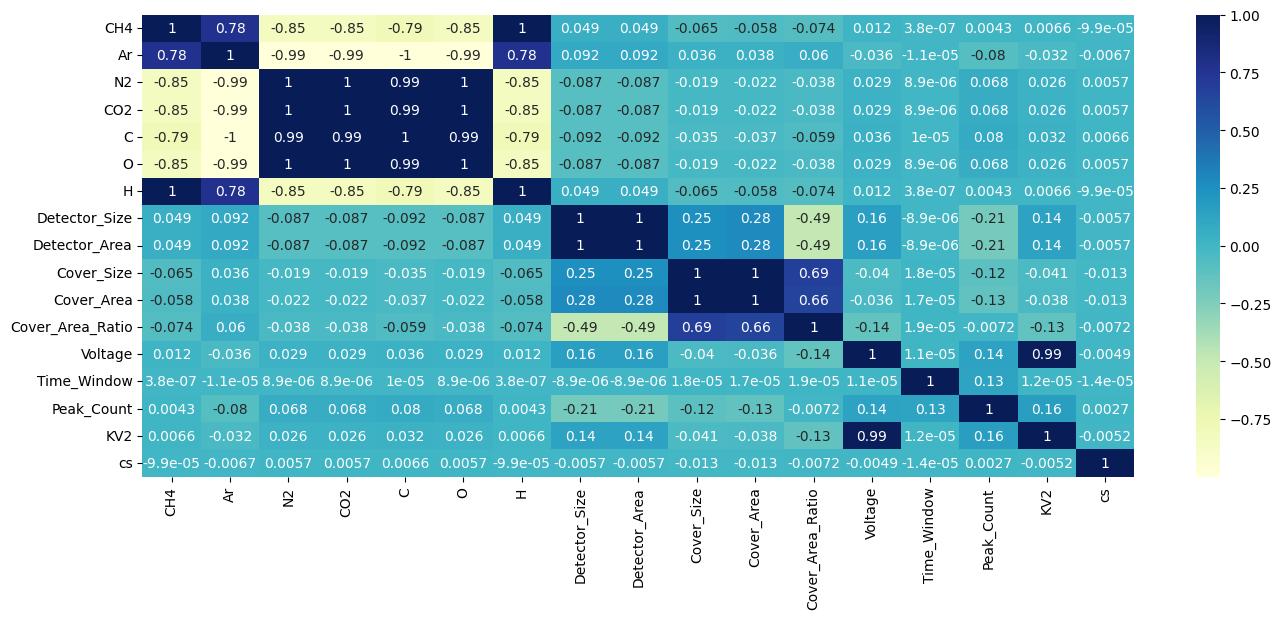

In [19]:
# creation of correlation matrix
corrM = data.corr()
plt.figure(figsize=(16, 6))
dataplot = sns.heatmap(corrM, cmap="YlGnBu", annot=True) 


In [20]:
corr = corrM[abs(corrM['Peak_Count'])>0.1][['Peak_Count']]
list(corr.index)

['Detector_Size',
 'Detector_Area',
 'Cover_Size',
 'Cover_Area',
 'Voltage',
 'Time_Window',
 'Peak_Count',
 'KV2']

In [21]:
#data=data[list(corr.index)]
data

,CH4,Ar,N2,CO2,C,O,H,Detector_Size,Detector_Area,Cover_Size,Cover_Area,Cover_Area_Ratio,Voltage,Time_Window,Peak_Count,KV2,cs
14616,0.1,0.90,0.00,0.0,0.02,0.0,0.08,10.00,100.00,8.00,64.00,0.64,3500,15,103,12.25,1.0
32323,0.2,0.80,0.00,0.0,0.04,0.0,0.16,10.00,100.00,4.00,16.00,0.16,5000,25,511,25.00,1.0
937,0.1,0.90,0.00,0.0,0.02,0.0,0.08,10.00,100.00,6.00,36.00,0.36,8000,15,918,64.00,0.0
61112,0.0,0.05,0.35,0.6,0.20,0.4,0.00,6.78,45.97,4.78,22.85,0.50,6500,25,2272,42.25,1.0
24276,0.1,0.90,0.00,0.0,0.02,0.0,0.08,6.78,45.97,6.68,44.62,0.97,8000,10,214,64.00,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35861,0.2,0.80,0.00,0.0,0.04,0.0,0.16,10.00,100.00,8.00,64.00,0.64,5500,25,316,30.25,0.0
64400,0.0,0.05,0.35,0.6,0.20,0.4,0.00,6.78,45.97,4.78,22.85,0.50,3500,10,574,12.25,0.0
17212,0.1,0.90,0.00,0.0,0.02,0.0,0.08,10.00,100.00,8.00,64.00,0.64,4500,15,236,20.25,1.0
40807,0.2,0.80,0.00,0.0,0.04,0.0,0.16,6.78,45.97,4.78,22.85,0.50,4000,15,2,16.00,1.0


In [22]:
from sklearn.model_selection import train_test_split

In [23]:
x=data.drop(['Peak_Count'],axis=1)

x.head()

,CH4,Ar,N2,CO2,C,O,H,Detector_Size,Detector_Area,Cover_Size,Cover_Area,Cover_Area_Ratio,Voltage,Time_Window,KV2,cs
14616,0.1,0.90,0.00,0.0,0.02,0.0,0.08,10.00,100.00,8.00,64.00,0.64,3500,15,12.25,1.0
32323,0.2,0.80,0.00,0.0,0.04,0.0,0.16,10.00,100.00,4.00,16.00,0.16,5000,25,25.00,1.0
937,0.1,0.90,0.00,0.0,0.02,0.0,0.08,10.00,100.00,6.00,36.00,0.36,8000,15,64.00,0.0
61112,0.0,0.05,0.35,0.6,0.20,0.4,0.00,6.78,45.97,4.78,22.85,0.50,6500,25,42.25,1.0
24276,0.1,0.90,0.00,0.0,0.02,0.0,0.08,6.78,45.97,6.68,44.62,0.97,8000,10,64.00,1.0


In [24]:
y=data['Peak_Count']
y

14616     103
32323     511
937       918
61112    2272
24276     214
         ... 
35861     316
64400     574
17212     236
40807       2
14847      81
Name: Peak_Count, Length: 7370, dtype: int64

In [25]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [26]:
from sklearn.linear_model import LinearRegression

In [27]:
model=LinearRegression()

In [28]:
model.fit(X_train,y_train)

LinearRegression()

In [29]:
pred=model.predict(X_test)
pred

array([279.32460311, 454.92569064, 816.2157904 , ..., 618.4130743 ,
       940.85948405, 774.31448671])

In [30]:
y_test

15096     219
4946       62
1177     1107
61811    1795
28779      93
         ... 
42231    1137
9420      234
41274       0
63465      99
58497     361
Name: Peak_Count, Length: 1474, dtype: int64

In [31]:
X_test

,CH4,Ar,N2,CO2,C,O,H,Detector_Size,Detector_Area,Cover_Size,Cover_Area,Cover_Area_Ratio,Voltage,Time_Window,KV2,cs
15096,0.1,0.90,0.00,0.0,0.02,0.0,0.08,10.00,100.00,8.00,64.00,0.64,6000,25,36.00,0.0
4946,0.1,0.90,0.00,0.0,0.02,0.0,0.08,10.00,100.00,6.00,36.00,0.36,7000,15,49.00,0.0
1177,0.1,0.90,0.00,0.0,0.02,0.0,0.08,10.00,100.00,6.00,36.00,0.36,7500,25,56.25,0.0
61811,0.0,0.05,0.35,0.6,0.20,0.4,0.00,6.78,45.97,4.78,22.85,0.50,3500,15,12.25,1.0
28779,0.2,0.80,0.00,0.0,0.04,0.0,0.16,10.00,100.00,6.00,36.00,0.36,5000,15,25.00,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42231,0.2,0.80,0.00,0.0,0.04,0.0,0.16,6.78,45.97,4.78,22.85,0.50,6500,15,42.25,1.0
9420,0.1,0.90,0.00,0.0,0.02,0.0,0.08,10.00,100.00,4.00,16.00,0.16,7000,15,49.00,1.0
41274,0.2,0.80,0.00,0.0,0.04,0.0,0.16,6.78,45.97,4.78,22.85,0.50,4000,10,16.00,0.0
63465,0.0,0.05,0.35,0.6,0.20,0.4,0.00,6.78,45.97,4.78,22.85,0.50,2000,15,4.00,0.0


In [32]:
model.score(X_test, y_test)

0.19587172889749316

In [33]:
pred

array([279.32460311, 454.92569064, 816.2157904 , ..., 618.4130743 ,
       940.85948405, 774.31448671])

In [34]:
y_test

15096     219
4946       62
1177     1107
61811    1795
28779      93
         ... 
42231    1137
9420      234
41274       0
63465      99
58497     361
Name: Peak_Count, Length: 1474, dtype: int64

In [35]:
indexes = X_test.index.values
#index=indexes[98]

In [36]:
#X_test.loc[index]

In [37]:
#y_test[index],pred[98]
pred[pred<=0] = 0

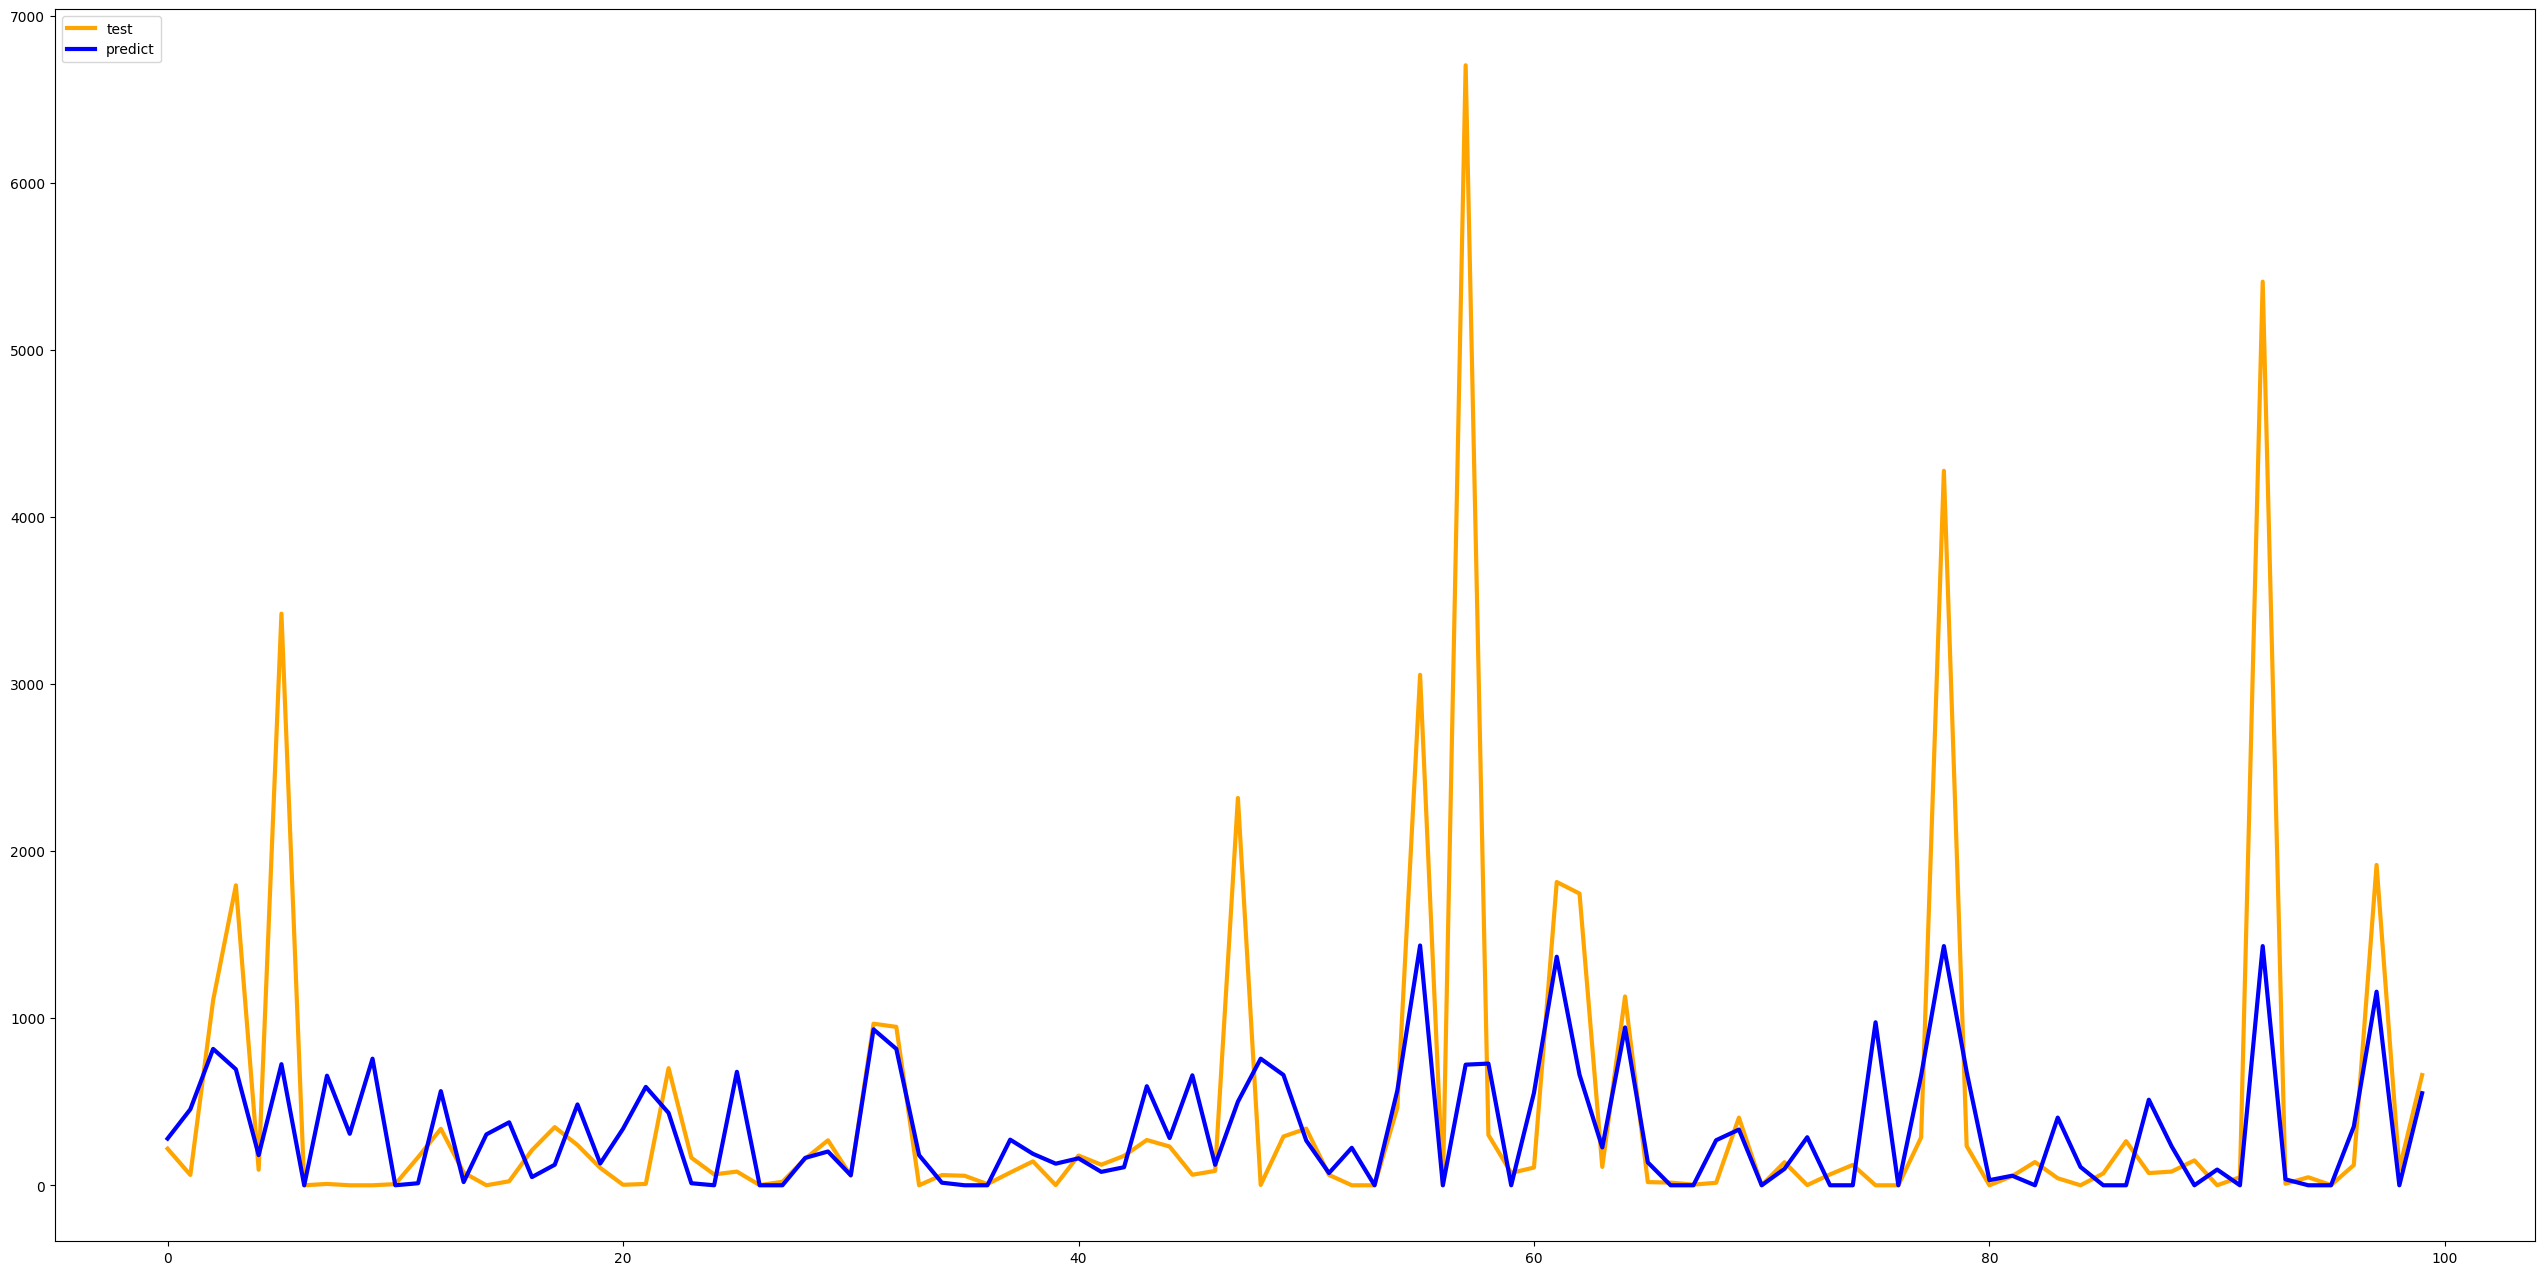

In [38]:
plt.figure(figsize=(32, 16))
plt.plot(range(0,len(indexes))[:100],y_test[:100], color="orange", linewidth=3 ,label = 'test')
plt.plot(range(0,len(indexes))[:100],pred[:100], color="blue", linewidth=3,label = 'predict')
plt.legend(loc="upper left")
plt.show()

In [39]:
indexes = X_test.index.values
#index=indexes[98]

In [40]:
#X_test.loc[index]

In [41]:
#y_test[index],pred[98]

In [42]:
#metrics.mean_absolute_error(y_true, y_pred, *) -> Mean absolute error regression loss.
metrics.mean_absolute_error(y_test, pred)

304.336325219416

In [43]:
#metrics.mean_squared_error(y_true, y_pred, *) -> Mean squared error regression loss.
metrics.mean_squared_error(y_test, pred)

566882.6194895231

In [44]:
#metrics.mean_squared_error(y_true, pred, *) -> Mean squared error regression loss.
metrics.mean_squared_error(y_test, pred)**0.5

752.9160773217179

In [45]:
#metrics.mean_absolute_percentage_error(...) -> Mean absolute percentage error (MAPE) regression loss.
metrics.mean_absolute_percentage_error(y_test, pred)

1.8074586924357235e+17

In [46]:
#metrics.r2_score(y_true, y_pred, *[, ...]) -> (coefficient of determination) regression score function.
metrics.r2_score(y_test, pred)

0.20550055076415052

In [47]:
metrics.explained_variance_score(y_test, pred)

0.2069254846234695

In [48]:
from pyGRNN import GRNN

In [49]:
model_grnn = GRNN(sigma=5)

In [142]:
dbfile = open('grnn_model.pickle', 'ab')
pickle.dump(model_grnn, dbfile)                    
dbfile.close()

In [50]:
model_grnn.fit(X_train,y_train)

Executing warm start...
Warm start concluded. The optimum isotropic sigma is [5.43456513]
Gradient search concluded. The optimum sigma is [4.88389014e+00 2.75576102e-03 4.18347208e+00 1.73209929e+00
 5.19897837e+00 3.79631787e+00 5.08686039e+00 5.43500000e+00
 5.43500000e+00 5.43829732e+00 5.73401609e+00 5.43489001e+00
 5.43500000e+00 2.04127160e+00 5.43500000e+00 1.31841010e-01]


GRNN(bnds=((0, None), (0, None), (0, None), (0, None), (0, None), (0, None),
           (0, None), (0, None), (0, None), (0, None), (0, None), (0, None),
           (0, None), (0, None), (0, None), (0, None)),
     sigma=array([4.88389014e+00, 2.75576102e-03, 4.18347208e+00, 1.73209929e+00,
       5.19897837e+00, 3.79631787e+00, 5.08686039e+00, 5.43500000e+00,
       5.43500000e+00, 5.43829732e+00, 5.73401609e+00, 5.43489001e+00,
       5.43500000e+00, 2.04127160e+00, 5.43500000e+00, 1.31841010e-01]))

In [51]:
pred_grnn=model_grnn.predict(X_test)
pred_grnn

array([252.49763902,  58.80894506, 411.68761054, ...,   0.87639472,
       352.18073635, 426.15347752])

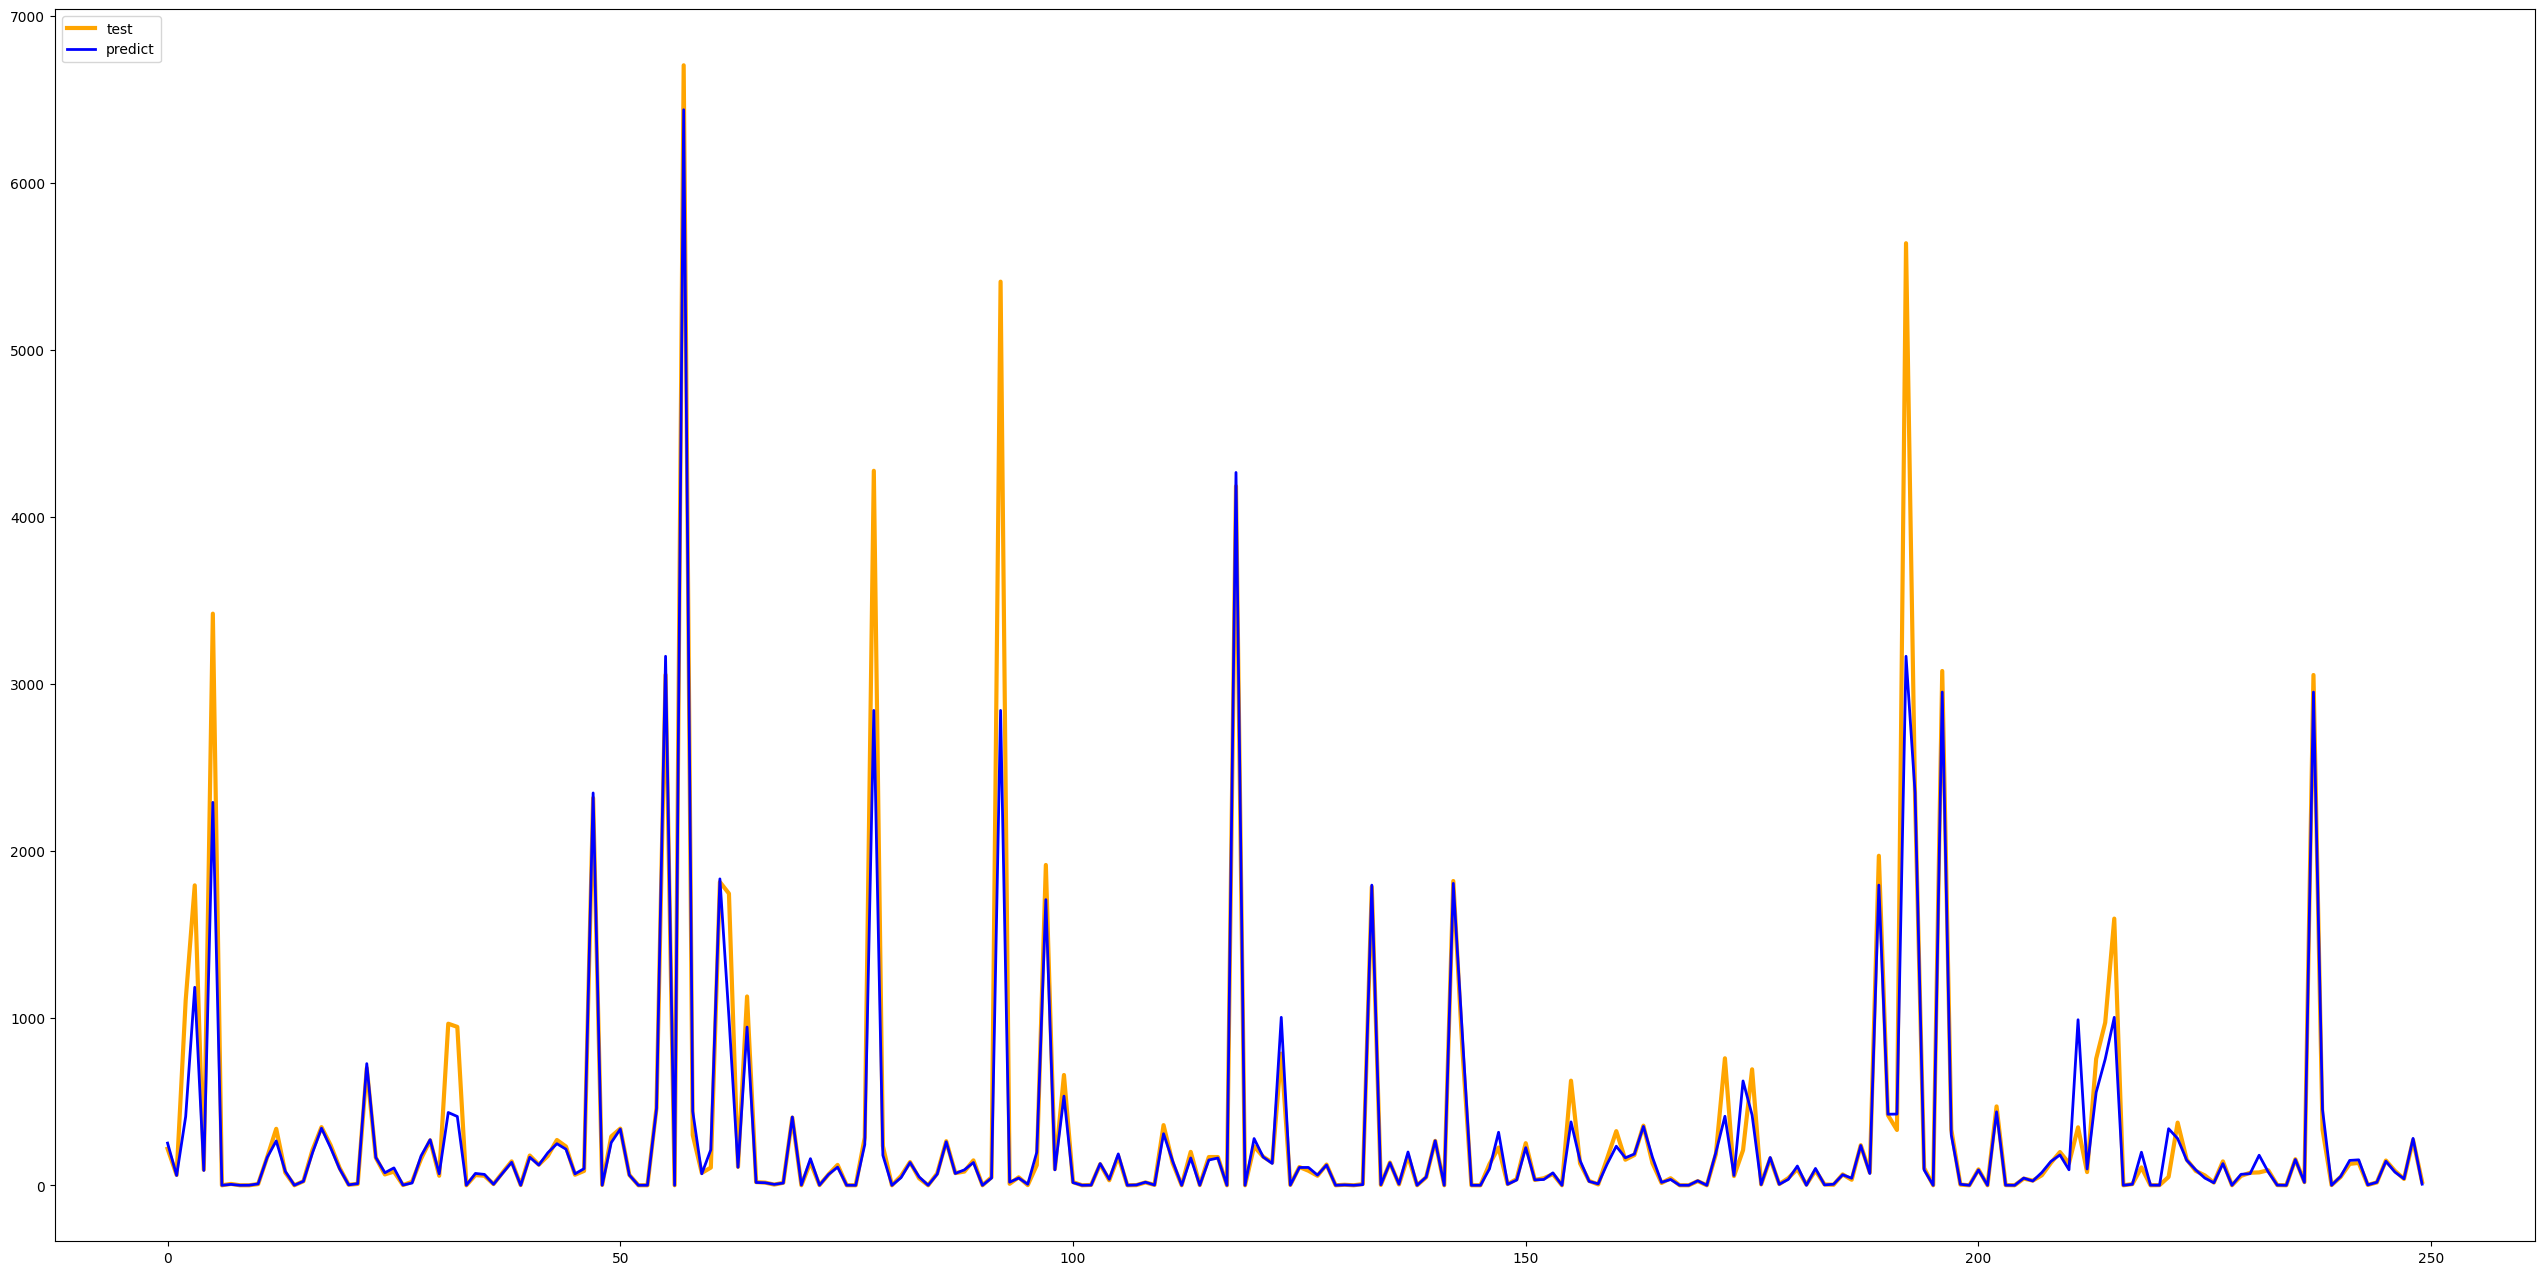

In [233]:
plt.figure(figsize=(32, 16))
plt.plot(range(0,len(indexes))[:250],y_test[:250], color="orange", linewidth=3 ,label = 'test')
plt.plot(range(0,len(indexes))[:250],pred_grnn[:250], color="blue", linewidth=2,label = 'predict')
plt.legend(loc="upper left")
plt.show()

In [53]:
#metrics.mean_absolute_error(y_true, y_pred, *) -> Mean absolute error regression loss.
metrics.mean_absolute_error(y_test, pred_grnn)

61.84117627402143

In [54]:
#metrics.mean_squared_error(y_true, y_pred, *) -> Mean squared error regression loss.
metrics.mean_squared_error(y_test, pred_grnn)

47794.81463435463

In [55]:
#metrics.mean_squared_error(y_true, pred, *) -> Mean squared error regression loss.
metrics.mean_squared_error(y_test, pred_grnn)**0.5

218.62025211392157

In [56]:
#metrics.mean_absolute_percentage_error(...) -> Mean absolute percentage error (MAPE) regression loss.
metrics.mean_absolute_percentage_error(y_test, pred_grnn)

117416796224184.64

In [57]:
#metrics.r2_score(y_true, y_pred, *[, ...]) -> (coefficient of determination) regression score function.
metrics.r2_score(y_test, pred_grnn)

0.9330144326218383

In [58]:
metrics.explained_variance_score(y_test, pred_grnn)

0.9333900478997543

In [61]:
row = data.loc[data.index.values[0]]
row

CH4                    0.10
Ar                     0.90
N2                     0.00
CO2                    0.00
C                      0.02
O                      0.00
H                      0.08
Detector_Size         10.00
Detector_Area        100.00
Cover_Size             8.00
Cover_Area            64.00
Cover_Area_Ratio       0.64
Voltage             3500.00
Time_Window           15.00
Peak_Count           103.00
KV2                   12.25
cs                     1.00
Name: 14616, dtype: float64

In [66]:
row = dict(row)
row

{'CH4': 0.1,
 'Ar': 0.9,
 'N2': 0.0,
 'CO2': 0.0,
 'C': 0.02,
 'O': 0.0,
 'H': 0.08,
 'Detector_Size': 10.0,
 'Detector_Area': 100.0,
 'Cover_Size': 8.0,
 'Cover_Area': 64.0,
 'Cover_Area_Ratio': 0.64,
 'Voltage': 3500.0,
 'Time_Window': 15.0,
 'Peak_Count': 103.0,
 'KV2': 12.25,
 'cs': 1.0}

In [225]:
row = {'CH4': 0.2,
 'Ar': 0.8,
 'N2': 0.0,
 'CO2': 0.0,
 'C': 0.04,
 'O': 0.0,
 'H': 0.16,
 'Detector_Size': 10.0,
 'Detector_Area': 100.0,
 'Cover_Size': 8.0,
 'Cover_Area': 64.0,
 'Cover_Area_Ratio': 0.64,
 'Voltage': 5500.0,
 'Time_Window': 15.0,
 'KV2': 12.25,
 'cs': 0.0}
df = pd.DataFrame.from_dict(row,orient='index').T
df

,CH4,Ar,N2,CO2,C,O,H,Detector_Size,Detector_Area,Cover_Size,Cover_Area,Cover_Area_Ratio,Voltage,Time_Window,KV2,cs
0,0.2,0.8,0.0,0.0,0.04,0.0,0.16,10.0,100.0,8.0,64.0,0.64,5500.0,15.0,12.25,0.0


In [226]:
model_grnn.predict(df)

array([193.59055413])